In [1]:
!pip install --upgrade pip

!pip install -q \
xgboost \
prophet \
shap \
python-multipart>=0.0.18

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
# ============================================================
# STEP 1: DATA CLEANING
# Pandemic Intelligence System
# ============================================================

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 1: DATA CLEANING & MERGING")
print("=" * 60)

# ── Create output directories ──────────────────────────────
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

# ── Load all raw datasets ──────────────────────────────────
print("\n📂 Loading raw datasets...")

DATA_PATH = "/kaggle/input/datasets/imdevskp/corona-virus-report/"

full_grouped = pd.read_csv(DATA_PATH + "full_grouped.csv")
covid_clean  = pd.read_csv(DATA_PATH + "covid_19_clean_complete.csv")
worldometer  = pd.read_csv(DATA_PATH + "worldometer_data.csv")
country_wise = pd.read_csv(DATA_PATH + "country_wise_latest.csv")
day_wise     = pd.read_csv(DATA_PATH + "day_wise.csv")

print(f"  full_grouped    : {full_grouped.shape}")
print(f"  covid_clean     : {covid_clean.shape}")
print(f"  worldometer     : {worldometer.shape}")
print(f"  country_wise    : {country_wise.shape}")
print(f"  day_wise        : {day_wise.shape}")

# ── Clean full_grouped ─────────────────────────────────────
print("\n🧹 Cleaning full_grouped...")

full_grouped.columns = full_grouped.columns.str.strip()
full_grouped['Date'] = pd.to_datetime(full_grouped['Date'])

# Rename for consistency
rename_map = {
    'Country/Region' : 'Country',
    'Province/State' : 'Province',
    'New cases'      : 'New_Cases',
    'New deaths'     : 'New_Deaths',
    'New recovered'  : 'New_Recovered',
    'Deaths / 100 Cases'    : 'Death_Rate_100',
    'Recovered / 100 Cases' : 'Recovery_Rate_100',
    'Deaths / 100 Recovered': 'Deaths_100_Recovered',
    'Confirmed last week'   : 'Confirmed_Last_Week',
    '1 week change'         : 'Week_Change',
    '1 week % increase'     : 'Week_Pct_Increase',
    'WHO Region'            : 'WHO_Region'
}
full_grouped.rename(columns={k: v for k, v in rename_map.items()
                              if k in full_grouped.columns}, inplace=True)

# Fill missing values
num_cols = full_grouped.select_dtypes(include=np.number).columns
full_grouped[num_cols] = full_grouped[num_cols].fillna(0)

# Remove negative values (data errors)
for col in ['Confirmed', 'Deaths', 'Recovered', 'Active']:
    if col in full_grouped.columns:
        full_grouped[col] = full_grouped[col].clip(lower=0)

print(f"  ✅ full_grouped cleaned: {full_grouped.shape}")

# ── Aggregate to country-day level ────────────────────────
print("\n🌍 Aggregating to Country-Day level...")

agg_cols = {c: 'sum' for c in ['Confirmed', 'Deaths', 'Recovered', 'Active',
                                 'New_Cases', 'New_Deaths', 'New_Recovered']
            if c in full_grouped.columns}
country_daily = (full_grouped
                 .groupby(['Date', 'Country'])
                 .agg(agg_cols)
                 .reset_index()
                 .sort_values(['Country', 'Date'])
                 .reset_index(drop=True))

print(f"  ✅ Country-daily shape: {country_daily.shape}")
print(f"  Countries: {country_daily['Country'].nunique()}")
print(f"  Date range: {country_daily['Date'].min()} → {country_daily['Date'].max()}")

# ── Clean worldometer ──────────────────────────────────────
print("\n🌐 Cleaning worldometer...")

worldometer.columns = worldometer.columns.str.strip()
worldometer_clean = worldometer.copy()
worldometer_clean.rename(columns={'Country/Region': 'Country'}, inplace=True)

# Clean numeric columns
wnum_cols = worldometer_clean.select_dtypes(include=np.number).columns
worldometer_clean[wnum_cols] = worldometer_clean[wnum_cols].fillna(0)

# Remove commas from string numbers if any
for col in worldometer_clean.columns:
    if worldometer_clean[col].dtype == object:
        try:
            worldometer_clean[col] = (worldometer_clean[col]
                                       .str.replace(',', '', regex=False)
                                       .str.replace('+', '', regex=False))
        except:
            pass

print(f"  ✅ Worldometer cleaned: {worldometer_clean.shape}")

# ── Clean day_wise ─────────────────────────────────────────
print("\n📅 Cleaning day_wise...")

day_wise.columns = day_wise.columns.str.strip()
day_wise['Date'] = pd.to_datetime(day_wise['Date'])
day_wise.fillna(0, inplace=True)
day_wise.rename(columns={
    'New cases'     : 'New_Cases',
    'New deaths'    : 'New_Deaths',
    'New recovered' : 'New_Recovered'
}, inplace=True)
print(f"  ✅ day_wise cleaned: {day_wise.shape}")

# ── Standardize country names ──────────────────────────────
print("\n🗺️  Standardizing country names...")

country_name_map = {
    'US'                           : 'United States',
    'Korea, South'                 : 'South Korea',
    'Taiwan*'                      : 'Taiwan',
    'Congo (Kinshasa)'             : 'DR Congo',
    'Congo (Brazzaville)'          : 'Congo',
    'Czechia'                      : 'Czech Republic',
    'Burma'                        : 'Myanmar',
    'West Bank and Gaza'           : 'Palestine',
    'Holy See'                     : 'Vatican',
    'Saint Kitts and Nevis'        : 'St. Kitts & Nevis',
    'Saint Lucia'                  : 'St. Lucia',
    'Saint Vincent and the Grenadines': 'St. Vincent & Grenadines',
    'Sao Tome and Principe'        : 'São Tomé & Príncipe',
    'Timor-Leste'                  : 'East Timor',
}

country_daily['Country'] = country_daily['Country'].replace(country_name_map)
worldometer_clean['Country'] = worldometer_clean['Country'].replace(country_name_map)
print(f"  ✅ Country names standardized")

# ── Validate data quality ──────────────────────────────────
print("\n🔍 Data Quality Report:")
print(f"  Missing values in country_daily : {country_daily.isnull().sum().sum()}")
print(f"  Missing values in worldometer   : {worldometer_clean.isnull().sum().sum()}")
print(f"  Duplicate rows country_daily    : {country_daily.duplicated().sum()}")

# ── Save cleaned data ──────────────────────────────────────
print("\n💾 Saving cleaned data...")
country_daily.to_csv('data/processed/cleaned_data.csv', index=False)
worldometer_clean.to_csv('data/processed/worldometer_clean.csv', index=False)
day_wise.to_csv('data/processed/day_wise_clean.csv', index=False)

print("\n" + "=" * 60)
print("✅ STEP 1 COMPLETE — Files saved to data/processed/")
print("=" * 60)
print("\nFiles created:")
print("  data/processed/cleaned_data.csv")
print("  data/processed/worldometer_clean.csv")
print("  data/processed/day_wise_clean.csv")

STEP 1: DATA CLEANING & MERGING

📂 Loading raw datasets...
  full_grouped    : (35156, 10)
  covid_clean     : (49068, 10)
  worldometer     : (209, 16)
  country_wise    : (187, 15)
  day_wise        : (188, 12)

🧹 Cleaning full_grouped...
  ✅ full_grouped cleaned: (35156, 10)

🌍 Aggregating to Country-Day level...
  ✅ Country-daily shape: (35156, 9)
  Countries: 187
  Date range: 2020-01-22 00:00:00 → 2020-07-27 00:00:00

🌐 Cleaning worldometer...
  ✅ Worldometer cleaned: (209, 16)

📅 Cleaning day_wise...
  ✅ day_wise cleaned: (188, 12)

🗺️  Standardizing country names...
  ✅ Country names standardized

🔍 Data Quality Report:
  Missing values in country_daily : 0
  Missing values in worldometer   : 26
  Duplicate rows country_daily    : 0

💾 Saving cleaned data...

✅ STEP 1 COMPLETE — Files saved to data/processed/

Files created:
  data/processed/cleaned_data.csv
  data/processed/worldometer_clean.csv
  data/processed/day_wise_clean.csv


In [3]:
# ============================================================
# STEP 2: FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 2: FEATURE ENGINEERING")
print("=" * 60)

# ── Load cleaned data ──────────────────────────────────────
df = pd.read_csv('data/processed/cleaned_data.csv', parse_dates=['Date'])
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
print(f"Loaded: {df.shape}")

# ── Group by country for feature creation ─────────────────
print("\n⚙️  Engineering features per country...")

def engineer_features(group):
    g = group.copy().sort_values('Date')
    
    # ── Rolling averages ───────────────────────────────────
    g['MA_7_Cases']     = g['Confirmed'].diff().rolling(7, min_periods=1).mean()
    g['MA_14_Cases']    = g['Confirmed'].diff().rolling(14, min_periods=1).mean()
    g['MA_7_Deaths']    = g['Deaths'].diff().rolling(7, min_periods=1).mean()
    g['MA_7_Recovered'] = g['Recovered'].diff().rolling(7, min_periods=1).mean()
    
    # ── Daily new cases (safeguard against negative diffs) ─
    g['Daily_Cases']     = g['Confirmed'].diff().clip(lower=0).fillna(0)
    g['Daily_Deaths']    = g['Deaths'].diff().clip(lower=0).fillna(0)
    g['Daily_Recovered'] = g['Recovered'].diff().clip(lower=0).fillna(0)
    
    # ── Growth rate (%) ────────────────────────────────────
    g['Growth_Rate'] = g['Daily_Cases'].pct_change() * 100
    g['Growth_Rate'] = g['Growth_Rate'].replace([np.inf, -np.inf], 0).fillna(0)
    g['Growth_Rate'] = g['Growth_Rate'].clip(-100, 500)
    
    # ── Case Fatality Rate (CFR) ───────────────────────────
    g['CFR'] = np.where(g['Confirmed'] > 0,
                        (g['Deaths'] / g['Confirmed']) * 100, 0)
    
    # ── Recovery rate ──────────────────────────────────────
    g['Recovery_Rate'] = np.where(g['Confirmed'] > 0,
                                   (g['Recovered'] / g['Confirmed']) * 100, 0)
    
    # ── Active ratio ───────────────────────────────────────
    g['Active_Ratio'] = np.where(g['Confirmed'] > 0,
                                  (g['Active'] / g['Confirmed']) * 100, 0)
    
    # ── Doubling time (days) ───────────────────────────────
    # Estimate: ln(2) / ln(1 + growth_rate/100)
    safe_gr = g['Growth_Rate'].clip(0.01, 500)
    g['Doubling_Time'] = np.log(2) / np.log(1 + safe_gr / 100)
    g['Doubling_Time'] = g['Doubling_Time'].replace([np.inf, -np.inf], 999).fillna(999)
    g['Doubling_Time'] = g['Doubling_Time'].clip(0, 999)
    
    # ── Acceleration of spread ─────────────────────────────
    g['Case_Acceleration'] = g['Daily_Cases'].diff().fillna(0)
    
    # ── Lag features for ML ────────────────────────────────
    for lag in [1, 3, 7, 14]:
        g[f'Cases_Lag_{lag}']  = g['Daily_Cases'].shift(lag).fillna(0)
        g[f'Deaths_Lag_{lag}'] = g['Daily_Deaths'].shift(lag).fillna(0)
    
    # ── Pandemic phase ─────────────────────────────────────
    max_cases = g['Daily_Cases'].max()
    if max_cases > 0:
        case_pct = g['Daily_Cases'] / max_cases
        g['Pandemic_Phase'] = pd.cut(
            case_pct,
            bins=[-0.01, 0.1, 0.5, 0.9, 1.01],
            labels=['Low', 'Growing', 'Peak', 'Declining']
        ).astype(str)
    else:
        g['Pandemic_Phase'] = 'Low'
    
    # ── Day of year / week features ────────────────────────
    g['Day_of_Year']  = g['Date'].dt.dayofyear
    g['Week_of_Year'] = g['Date'].dt.isocalendar().week.astype(int)
    g['Month']        = g['Date'].dt.month
    g['Days_Since_Start'] = (g['Date'] - g['Date'].min()).dt.days
    
    # ── Cumulative growth factor ───────────────────────────
    first_confirmed = g['Confirmed'].replace(0, np.nan).iloc[0]
    if pd.notna(first_confirmed) and first_confirmed > 0:
        g['Growth_Factor'] = g['Confirmed'] / first_confirmed
    else:
        g['Growth_Factor'] = 1.0
    
    return g

feature_df = df.groupby('Country', group_keys=False).apply(engineer_features)
feature_df = feature_df.reset_index(drop=True)

# ── Fill any remaining NaNs ────────────────────────────────
feature_df.fillna(0, inplace=True)

# ── Merge worldometer data (adds healthcare indicators) ───
print("\n🔗 Merging worldometer data...")
worldometer = pd.read_csv('data/processed/worldometer_clean.csv')
worldometer_subset = worldometer[['Country', 'Tests/ 1M pop', 'Deaths/ 1M pop',
                                   'Serious,Critical', 'Tot Cases/1M pop']
                                  ].copy() if 'Tests/ 1M pop' in worldometer.columns else worldometer[['Country']].copy()
feature_df = feature_df.merge(worldometer_subset, on='Country', how='left')
feature_df.fillna(0, inplace=True)

print(f"\n✅ Feature engineering complete!")
print(f"   Shape: {feature_df.shape}")
print(f"   Features created: {feature_df.shape[1] - df.shape[1]}")
print(f"\n   New columns:")
new_cols = [c for c in feature_df.columns if c not in df.columns]
for c in new_cols:
    print(f"     • {c}")

# ── Save ───────────────────────────────────────────────────
feature_df.to_csv('data/processed/features_data.csv', index=False)

print("\n" + "=" * 60)
print("✅ STEP 2 COMPLETE — data/processed/features_data.csv saved")
print("=" * 60)

STEP 2: FEATURE ENGINEERING
Loaded: (35156, 9)

⚙️  Engineering features per country...

🔗 Merging worldometer data...

✅ Feature engineering complete!
   Shape: (35156, 36)
   Features created: 27

   New columns:
     • MA_7_Cases
     • MA_14_Cases
     • MA_7_Deaths
     • MA_7_Recovered
     • Daily_Cases
     • Daily_Deaths
     • Daily_Recovered
     • Growth_Rate
     • CFR
     • Recovery_Rate
     • Active_Ratio
     • Doubling_Time
     • Case_Acceleration
     • Cases_Lag_1
     • Deaths_Lag_1
     • Cases_Lag_3
     • Deaths_Lag_3
     • Cases_Lag_7
     • Deaths_Lag_7
     • Cases_Lag_14
     • Deaths_Lag_14
     • Pandemic_Phase
     • Day_of_Year
     • Week_of_Year
     • Month
     • Days_Since_Start
     • Growth_Factor

✅ STEP 2 COMPLETE — data/processed/features_data.csv saved


STEP 3: ADVANCED EDA

📈 3.1 Global Pandemic Timeline...


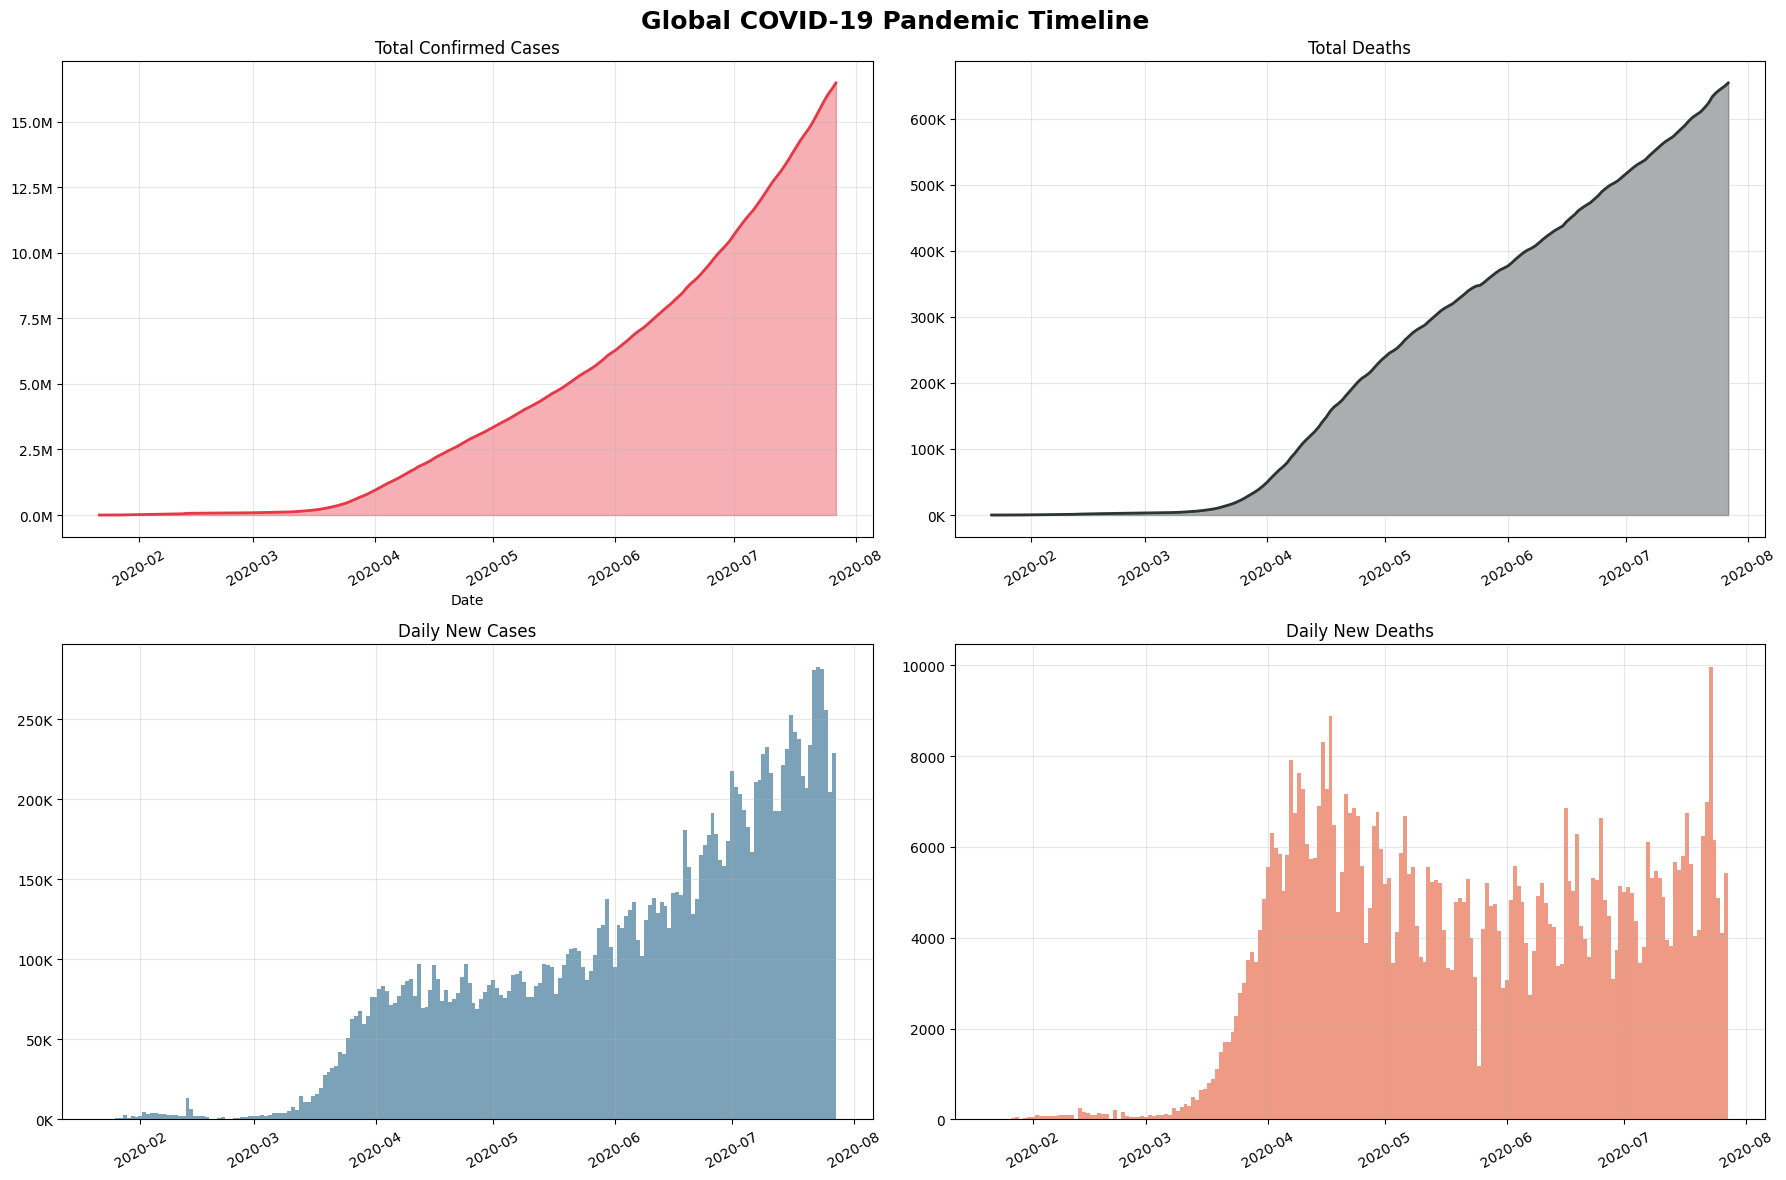

  ✅ Saved 01_global_trend.png

🌍 3.2 Top Countries Comparison...


  ✅ Saved 02_top_countries_confirmed.html

🌊 3.3 Wave Detection...


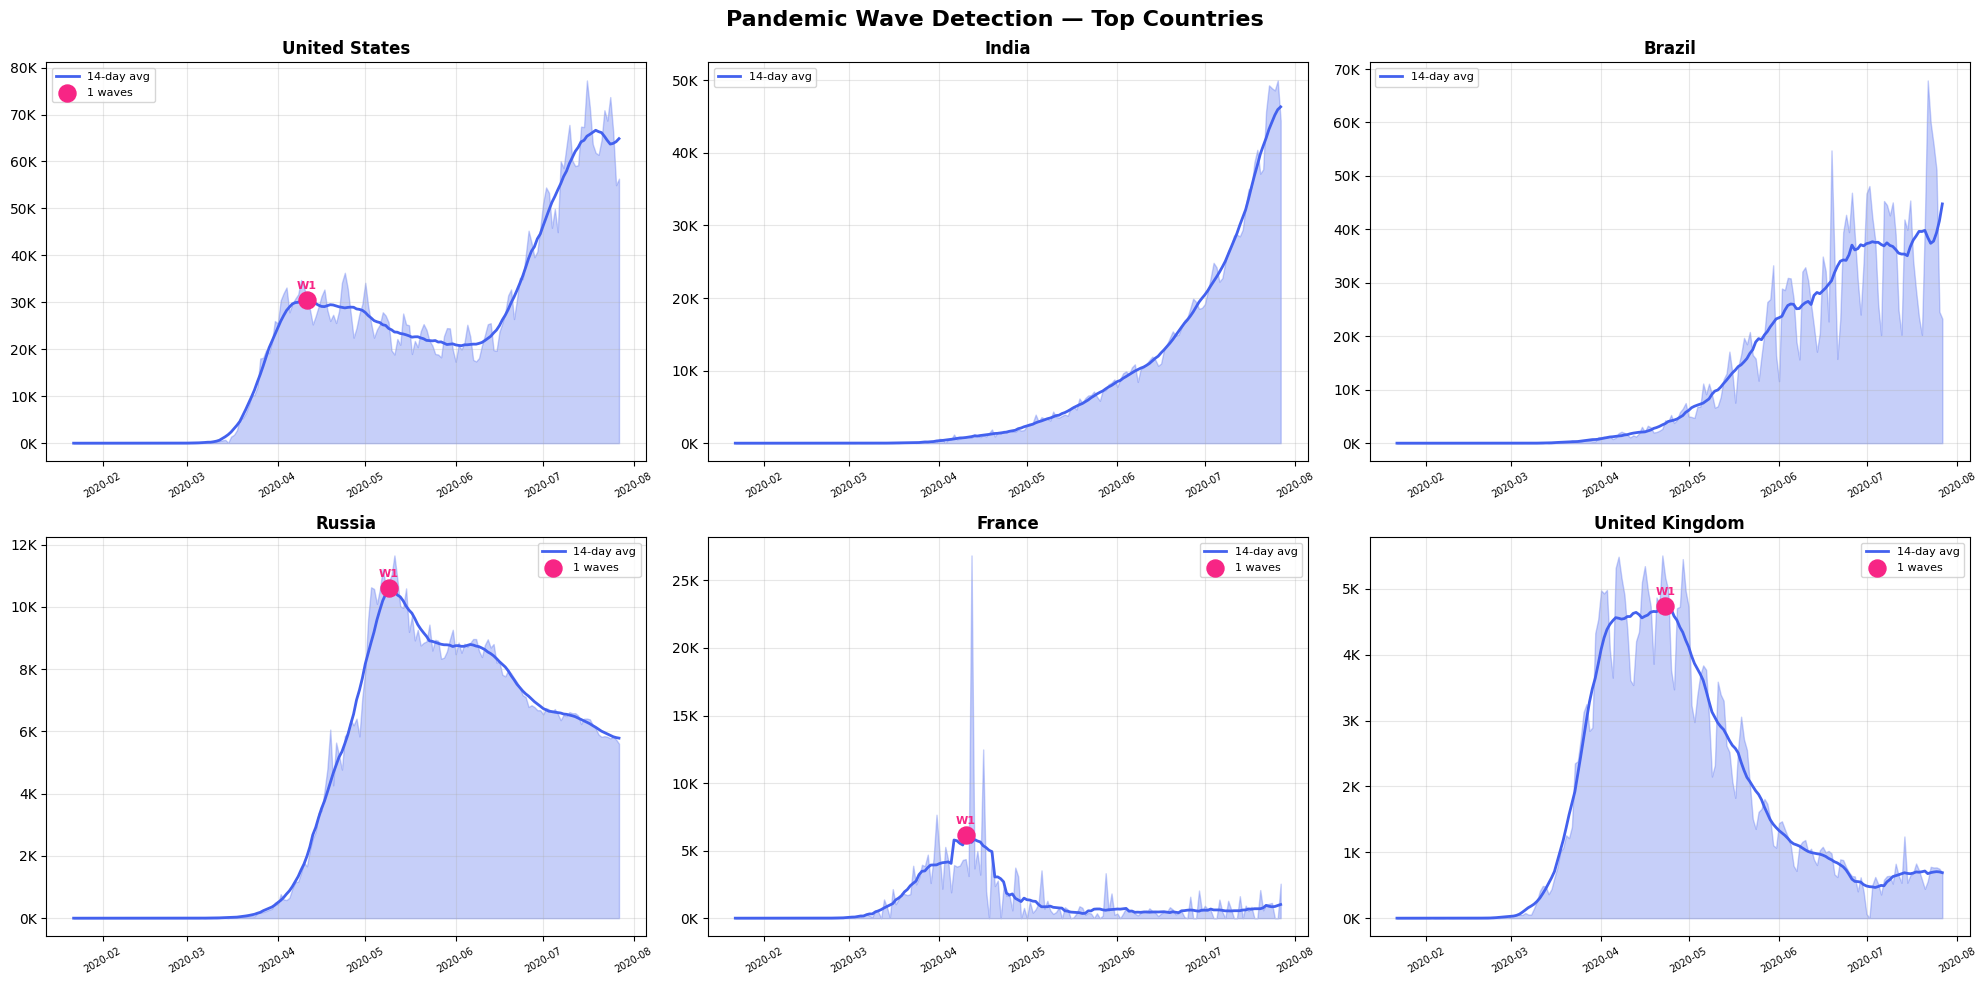

  ✅ Saved 03_wave_detection.png

🔵 3.4 Country Clustering (K-Means)...


  ✅ Saved 04_country_clusters.html

🔥 3.5 Correlation Heatmap...


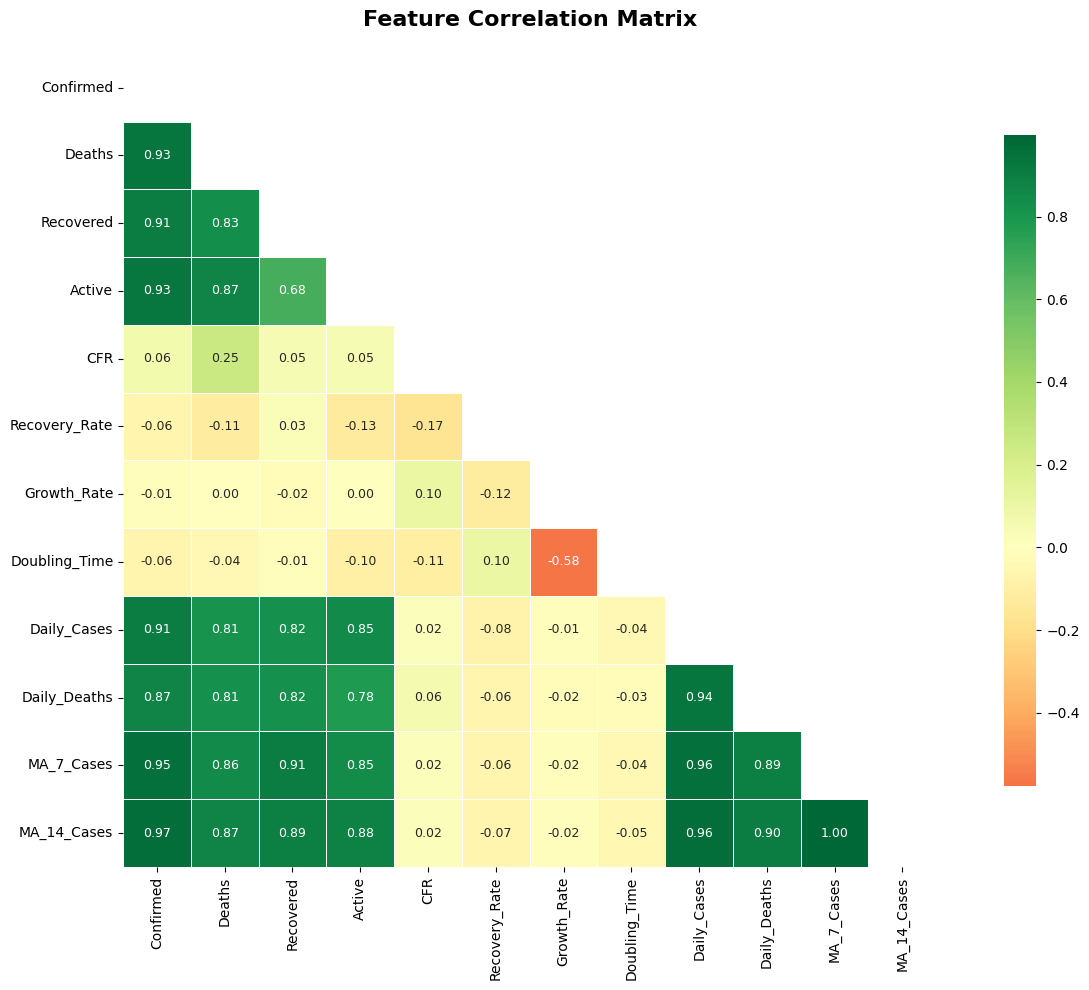

  ✅ Saved 05_correlation_heatmap.png

⚖️  3.6 CFR vs Recovery Rate...


  ✅ Saved 06_cfr_vs_recovery.html

🗺️  3.7 Global Case Distribution Treemap...


  ✅ Saved 07_treemap.html

💀 3.8 Death Rate Distribution...


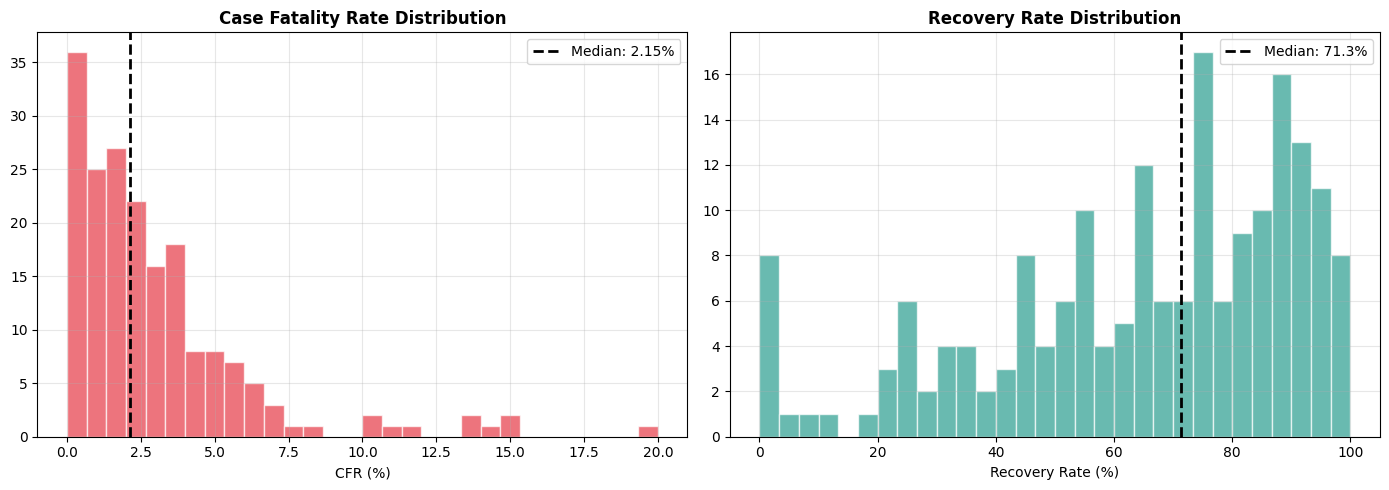

  ✅ Saved 08_distributions.png

✅ STEP 3 COMPLETE — All plots saved to data/eda_outputs/

Files created in data/eda_outputs/:
  • 01_global_trend.png
  • 02_top_countries_confirmed.html
  • 03_wave_detection.png
  • 04_country_clusters.html
  • 05_correlation_heatmap.png
  • 06_cfr_vs_recovery.html
  • 07_treemap.html
  • 08_distributions.png


In [4]:
# ============================================================
# STEP 3: ADVANCED EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

os.makedirs('data/eda_outputs', exist_ok=True)
import os

print("=" * 60)
print("STEP 3: ADVANCED EDA")
print("=" * 60)

df = pd.read_csv('data/processed/features_data.csv', parse_dates=['Date'])
wm = pd.read_csv('data/processed/worldometer_clean.csv')
dw = pd.read_csv('data/processed/day_wise_clean.csv', parse_dates=['Date'])

TOP_COUNTRIES = ['United States', 'India', 'Brazil', 'Russia',
                  'France', 'United Kingdom', 'Italy', 'Germany',
                  'Spain', 'Mexico']

# ── 3.1 Global Trend ──────────────────────────────────────
print("\n📈 3.1 Global Pandemic Timeline...")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Global COVID-19 Pandemic Timeline', fontsize=18, fontweight='bold')

axes[0,0].fill_between(dw['Date'], dw['Confirmed'], alpha=0.4, color='#e63946')
axes[0,0].plot(dw['Date'], dw['Confirmed'], color='#e63946', linewidth=2)
axes[0,0].set_title('Total Confirmed Cases')
axes[0,0].set_xlabel('Date')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[0,1].fill_between(dw['Date'], dw['Deaths'], alpha=0.4, color='#2d3436')
axes[0,1].plot(dw['Date'], dw['Deaths'], color='#2d3436', linewidth=2)
axes[0,1].set_title('Total Deaths')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

if 'New_Cases' in dw.columns:
    axes[1,0].bar(dw['Date'], dw['New_Cases'], color='#457b9d', alpha=0.7, width=1)
    axes[1,0].set_title('Daily New Cases')
    axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

if 'New_Deaths' in dw.columns:
    axes[1,1].bar(dw['Date'], dw['New_Deaths'], color='#e76f51', alpha=0.7, width=1)
    axes[1,1].set_title('Daily New Deaths')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/eda_outputs/01_global_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved 01_global_trend.png")

# ── 3.2 Top Countries Comparison ──────────────────────────
print("\n🌍 3.2 Top Countries Comparison...")
top_df = df[df['Country'].isin(TOP_COUNTRIES)]

fig = px.line(
    top_df,
    x='Date', y='Confirmed', color='Country',
    title='Top 10 Countries — Total Confirmed Cases Over Time',
    labels={'Confirmed': 'Total Confirmed', 'Date': ''},
    template='plotly_white'
)
fig.update_layout(height=500, legend=dict(orientation='h', y=-0.15))
fig.write_html('data/eda_outputs/02_top_countries_confirmed.html')
fig.show()
print("  ✅ Saved 02_top_countries_confirmed.html")

# ── 3.3 Wave Detection ────────────────────────────────────
print("\n🌊 3.3 Wave Detection...")

def detect_waves(series, prominence_threshold=0.1):
    """Detect pandemic waves using local maxima."""
    from scipy.signal import find_peaks
    max_val = series.max()
    if max_val == 0:
        return np.array([])
    normalized = series / max_val
    peaks, properties = find_peaks(
        normalized,
        prominence=prominence_threshold,
        distance=21
    )
    return peaks

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Pandemic Wave Detection — Top Countries', fontsize=16, fontweight='bold')

for i, (ax, country) in enumerate(zip(axes.flatten(), TOP_COUNTRIES[:6])):
    cdf = df[df['Country'] == country].sort_values('Date')
    if len(cdf) == 0:
        continue
    
    daily = cdf['Daily_Cases'].values
    dates = cdf['Date'].values
    
    # Smooth for wave detection
    from scipy.ndimage import uniform_filter1d
    smoothed = uniform_filter1d(daily.astype(float), size=14)
    
    ax.fill_between(dates, daily, alpha=0.3, color='#4361ee')
    ax.plot(dates, smoothed, color='#4361ee', linewidth=2, label='14-day avg')
    
    # Detect peaks
    peaks = detect_waves(smoothed)
    if len(peaks) > 0:
        ax.scatter(dates[peaks], smoothed[peaks],
                   color='#f72585', s=150, zorder=5, label=f'{len(peaks)} waves')
        for j, p in enumerate(peaks, 1):
            ax.annotate(f'W{j}', (dates[p], smoothed[p]),
                       textcoords='offset points', xytext=(0,8),
                       fontsize=8, ha='center', color='#f72585', fontweight='bold')
    
    ax.set_title(country, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('data/eda_outputs/03_wave_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved 03_wave_detection.png")

# ── 3.4 Country Clustering ────────────────────────────────
print("\n🔵 3.4 Country Clustering (K-Means)...")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Latest snapshot per country
latest = df.groupby('Country').last().reset_index()

cluster_features = ['Confirmed', 'Deaths', 'Recovered', 'Active',
                    'CFR', 'Recovery_Rate', 'Growth_Rate']
cluster_features = [f for f in cluster_features if f in latest.columns]

X = latest[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
latest['Cluster'] = kmeans.fit_predict(X_scaled).astype(str)

# PCA for visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
latest['PCA1'] = pca_coords[:, 0]
latest['PCA2'] = pca_coords[:, 1]

fig = px.scatter(
    latest, x='PCA1', y='PCA2',
    color='Cluster', hover_name='Country',
    size='Confirmed', size_max=40,
    title=f'Country Clustering (K-Means, k=5) — PCA Projection<br>'
          f'<sup>Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%</sup>',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(height=600)
fig.write_html('data/eda_outputs/04_country_clusters.html')
fig.show()
print("  ✅ Saved 04_country_clusters.html")

# ── 3.5 Correlation Heatmap ───────────────────────────────
print("\n🔥 3.5 Correlation Heatmap...")

corr_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active',
             'CFR', 'Recovery_Rate', 'Growth_Rate', 'Doubling_Time',
             'Daily_Cases', 'Daily_Deaths', 'MA_7_Cases', 'MA_14_Cases']
corr_cols = [c for c in corr_cols if c in latest.columns]

corr_matrix = latest[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('data/eda_outputs/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved 05_correlation_heatmap.png")

# ── 3.6 CFR vs Recovery Rate Scatter ─────────────────────
print("\n⚖️  3.6 CFR vs Recovery Rate...")

fig = px.scatter(
    latest[latest['Confirmed'] > 1000],
    x='CFR', y='Recovery_Rate',
    size='Confirmed', color='Active',
    hover_name='Country',
    title='Case Fatality Rate vs Recovery Rate by Country',
    labels={'CFR': 'Case Fatality Rate (%)', 'Recovery_Rate': 'Recovery Rate (%)'},
    template='plotly_white',
    color_continuous_scale='RdYlGn_r'
)
fig.update_layout(height=550)
fig.write_html('data/eda_outputs/06_cfr_vs_recovery.html')
fig.show()
print("  ✅ Saved 06_cfr_vs_recovery.html")

# ── 3.7 Treemap of case distribution ─────────────────────
print("\n🗺️  3.7 Global Case Distribution Treemap...")

treemap_df = latest[latest['Confirmed'] > 0].nlargest(50, 'Confirmed')
fig = px.treemap(
    treemap_df,
    path=['Country'], values='Confirmed',
    color='CFR', color_continuous_scale='RdYlGn_r',
    title='Top 50 Countries — Case Distribution & CFR',
    template='plotly_white'
)
fig.update_layout(height=600)
fig.write_html('data/eda_outputs/07_treemap.html')
fig.show()
print("  ✅ Saved 07_treemap.html")

# ── 3.8 Death Rate Distribution ───────────────────────────
print("\n💀 3.8 Death Rate Distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(latest['CFR'].clip(0, 20), bins=30, color='#e63946',
              alpha=0.7, edgecolor='white')
axes[0].axvline(latest['CFR'].median(), color='black', linestyle='--',
                linewidth=2, label=f"Median: {latest['CFR'].median():.2f}%")
axes[0].set_title('Case Fatality Rate Distribution', fontweight='bold')
axes[0].set_xlabel('CFR (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(latest['Recovery_Rate'].clip(0, 100), bins=30,
              color='#2a9d8f', alpha=0.7, edgecolor='white')
axes[1].axvline(latest['Recovery_Rate'].median(), color='black', linestyle='--',
                linewidth=2, label=f"Median: {latest['Recovery_Rate'].median():.1f}%")
axes[1].set_title('Recovery Rate Distribution', fontweight='bold')
axes[1].set_xlabel('Recovery Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/eda_outputs/08_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved 08_distributions.png")

print("\n" + "=" * 60)
print("✅ STEP 3 COMPLETE — All plots saved to data/eda_outputs/")
print("=" * 60)
print(f"\nFiles created in data/eda_outputs/:")
for f in sorted(os.listdir('data/eda_outputs/')):
    print(f"  • {f}")

STEP 4: TIME SERIES FORECASTING

📊 MODEL 1: ARIMA (Baseline)
----------------------------------------
  ✅ United States: order=(2, 1, 2) | RMSE=20,017 | MAE=17,922
  ✅ India: order=(1, 1, 2) | RMSE=6,631 | MAE=4,516
  ✅ Brazil: order=(2, 1, 2) | RMSE=12,275 | MAE=10,252
  ✅ United Kingdom: order=(2, 1, 2) | RMSE=246 | MAE=173

📊 MODEL 2: SARIMA (Intermediate)
----------------------------------------
  ✅ United States: order=(2, 1, 2), seasonal=(1, 1, 1, 7) | RMSE=6,053 | MAE=4,640
  ✅ India: order=(2, 1, 2), seasonal=(1, 1, 1, 7) | RMSE=8,187 | MAE=5,762
  ✅ Brazil: order=(2, 1, 2), seasonal=(1, 1, 1, 7) | RMSE=13,819 | MAE=11,707
  ✅ United Kingdom: order=(2, 1, 2), seasonal=(1, 1, 1, 7) | RMSE=364 | MAE=291

🧠 MODEL 3: LSTM (Deep Learning)
----------------------------------------

  Training United States...
    Epoch  20/80 | Loss: 0.008304
    Epoch  40/80 | Loss: 0.005872
    Epoch  60/80 | Loss: 0.003588
    Epoch  80/80 | Loss: 0.001569
  ✅ United States: RMSE=23,473 | MAE=21,42

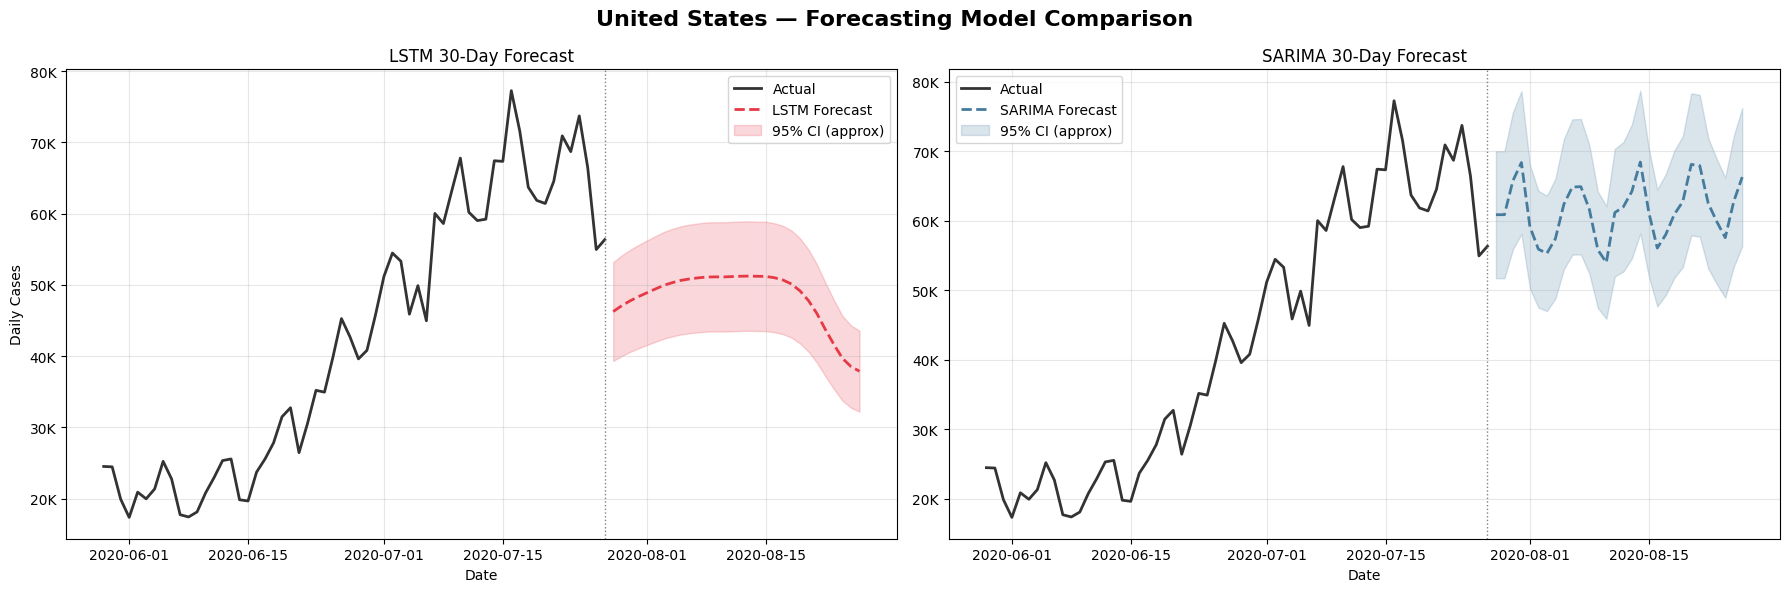

  ✅ Saved data/forecast_outputs/forecast_united_states.png


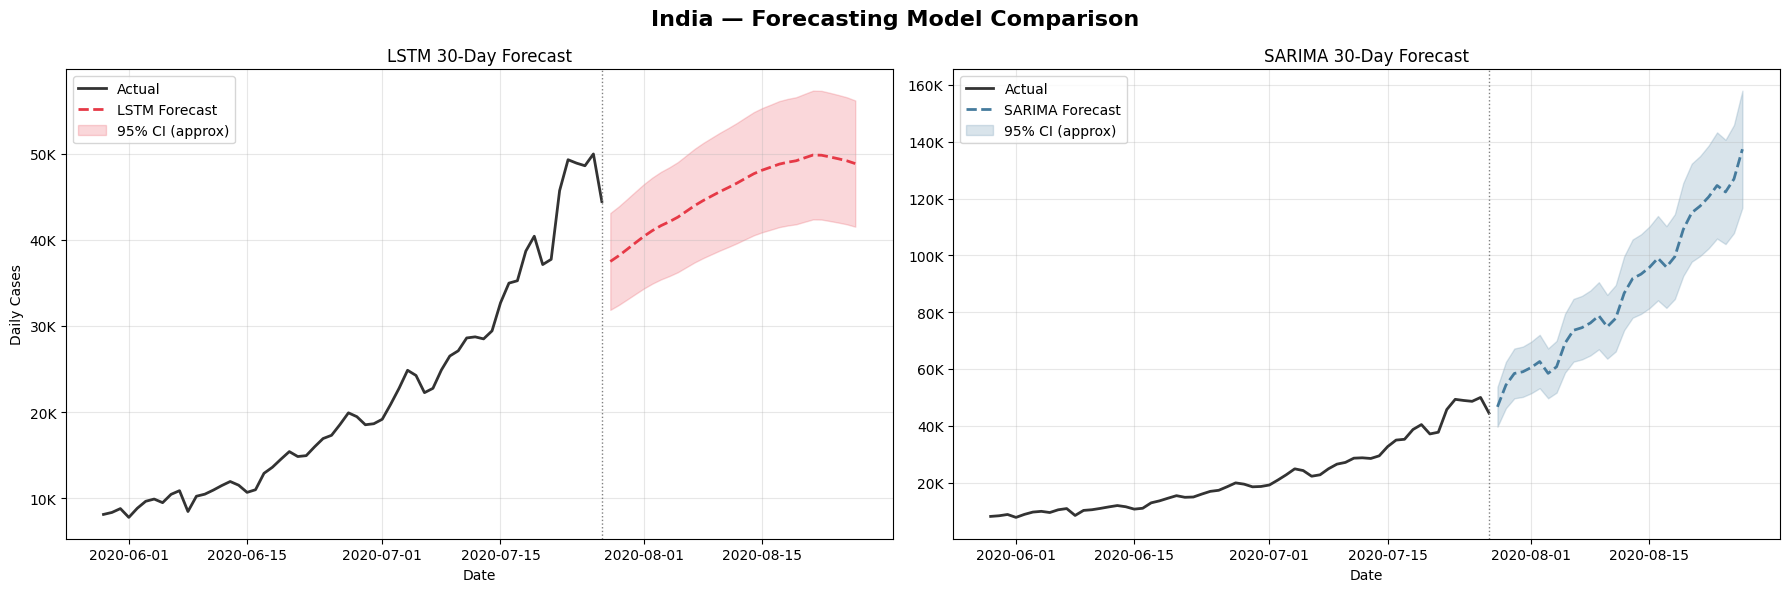

  ✅ Saved data/forecast_outputs/forecast_india.png

  ✅ Model comparison saved: data/forecast_outputs/model_metrics_comparison.csv

✅ STEP 4 COMPLETE — Models saved to models/


In [6]:
# ============================================================
# STEP 4: TIME SERIES FORECASTING
# Models: ARIMA → SARIMA → LSTM → Save
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import joblib
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
os.makedirs('data/forecast_outputs', exist_ok=True)

print("=" * 60)
print("STEP 4: TIME SERIES FORECASTING")
print("=" * 60)

df = pd.read_csv('data/processed/features_data.csv', parse_dates=['Date'])

# ── Config ────────────────────────────────────────────────
TARGET_COUNTRIES = ['United States', 'India', 'Brazil', 'United Kingdom']
TARGET_COL       = 'Daily_Cases'
FORECAST_DAYS    = [7, 14, 30]

# ── Metrics helper ────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calc_metrics(actual, predicted):
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + 1))) * 100
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

all_results = {}

# ══════════════════════════════════════════════════════════
# MODEL 1: ARIMA (Baseline)
# ══════════════════════════════════════════════════════════
print("\n📊 MODEL 1: ARIMA (Baseline)")
print("-" * 40)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

def run_arima(series, forecast_steps=30):
    """Auto-fit ARIMA with ADF test for differencing order."""
    series = series.copy()
    
    # ADF Test
    adf_result = adfuller(series.dropna())
    d = 0 if adf_result[1] < 0.05 else 1
    
    best_aic = np.inf
    best_order = (2, d, 2)
    
    # Grid search (small grid for speed)
    for p in [1, 2]:
        for q in [0, 1, 2]:
            try:
                m = ARIMA(series, order=(p, d, q))
                res = m.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, d, q)
            except:
                pass
    
    model = ARIMA(series, order=best_order)
    result = model.fit()
    forecast = result.forecast(steps=forecast_steps)
    return forecast, best_order, result

arima_forecasts = {}

for country in TARGET_COUNTRIES:
    cdf = df[df['Country'] == country].sort_values('Date')
    if len(cdf) < 60:
        print(f"  ⚠️  {country}: insufficient data, skipping")
        continue
    
    series = cdf[TARGET_COL].values.astype(float)
    series = pd.Series(series).clip(lower=0)
    
    # Train/test split (last 30 days = test)
    train, test = series[:-30], series[-30:]
    
    try:
        forecast, order, fitted = run_arima(train, forecast_steps=30)
        forecast = np.maximum(forecast, 0)
        metrics = calc_metrics(test.values, forecast[:30])
        
        arima_forecasts[country] = {
            'forecast': forecast,
            'order': order,
            'metrics': metrics,
            'dates': cdf['Date'].values
        }
        
        print(f"  ✅ {country}: order={order} | RMSE={metrics['RMSE']:,.0f} | MAE={metrics['MAE']:,.0f}")
    except Exception as e:
        print(f"  ❌ {country}: {e}")

# ══════════════════════════════════════════════════════════
# MODEL 2: SARIMA (Intermediate - Seasonal ARIMA)
# ══════════════════════════════════════════════════════════
print("\n📊 MODEL 2: SARIMA (Intermediate)")
print("-" * 40)

from statsmodels.tsa.statespace.sarimax import SARIMAX

def run_sarima(series, forecast_steps=30):
    """
    SARIMA model with weekly seasonality (s=7)
    Suitable for COVID time-series patterns
    """
    series = pd.Series(series).astype(float).clip(lower=0)

    # Default strong configuration (can tune later)
    order = (2, 1, 2)
    seasonal_order = (1, 1, 1, 7)  # weekly seasonality

    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)
    forecast = result.forecast(steps=forecast_steps)

    return forecast, order, seasonal_order, result


sarima_forecasts = {}

for country in TARGET_COUNTRIES:
    cdf = df[df['Country'] == country].sort_values('Date')

    if len(cdf) < 60:
        print(f"  ⚠️ {country}: insufficient data")
        continue

    series = cdf[TARGET_COL].values.astype(float)
    series = np.maximum(series, 0)

    # Train/test split
    train, test = series[:-30], series[-30:]

    try:
        # Test forecast for metrics
        forecast, order, seasonal_order, fitted = run_sarima(train, forecast_steps=30)
        forecast = np.maximum(forecast, 0)
        metrics = calc_metrics(test, forecast[:30])
        
        # Future forecast for plotting (trained on full series)
        future_forecast, _, _, _ = run_sarima(series, forecast_steps=30)
        future_forecast = np.maximum(future_forecast, 0)

        sarima_forecasts[country] = {
            'test_forecast': forecast,
            'future_forecast': future_forecast.values,
            'order': order,
            'seasonal_order': seasonal_order,
            'metrics': metrics
        }

        print(f"  ✅ {country}: order={order}, seasonal={seasonal_order} | "
              f"RMSE={metrics['RMSE']:,.0f} | MAE={metrics['MAE']:,.0f}")

    except Exception as e:
        print(f"  ❌ {country}: {e}")

# ══════════════════════════════════════════════════════════
# MODEL 3: LSTM (Deep Learning — MAIN MODEL)
# ══════════════════════════════════════════════════════════
print("\n🧠 MODEL 3: LSTM (Deep Learning)")
print("-" * 40)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# LSTM Architecture
class PandemicLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2,
                 output_size=1, dropout=0.2):
        super(PandemicLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.attention = nn.MultiheadAttention(hidden_size, num_heads=4,
                                               batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, output_size)
        )
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        attn_out, _ = self.attention(out, out, out)
        out = self.fc(attn_out[:, -1, :])
        return out

def create_sequences(data, seq_len=30):
    """Create sliding window sequences."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

def train_lstm(series, country_name, seq_len=30, epochs=100, batch_size=32):
    """Full LSTM training pipeline."""
    
    series = np.array(series).astype(float)
    series = np.maximum(series, 0)
    
    # Scale
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(series.reshape(-1, 1))
    
    # Sequences
    X, y = create_sequences(scaled.flatten(), seq_len)
    
    if len(X) < 20:
        return None, None, None
    
    # Train/test split
    split = int(len(X) * 0.85)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Tensors
    X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)
    X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1)
    y_test_t  = torch.FloatTensor(y_test).unsqueeze(-1)
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model     = PandemicLSTM(input_size=1, hidden_size=128, num_layers=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5)
    criterion = nn.HuberLoss()
    
    best_loss = np.inf
    best_state = None
    train_losses = []
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        
        if (epoch + 1) % 20 == 0:
            print(f"    Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f}")
    
    # Load best
    model.load_state_dict(best_state)
    model.eval()
    
    # Evaluate on test
    with torch.no_grad():
        test_pred = model(X_test_t).numpy()
    
    test_pred = scaler.inverse_transform(test_pred)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    test_pred = np.maximum(test_pred, 0)
    
    metrics = calc_metrics(y_test_actual.flatten(), test_pred.flatten())
    
    return model, scaler, metrics

def forecast_future_lstm(model, scaler, series, steps=30, seq_len=30):
    """Multi-step future forecasting with LSTM."""
    model.eval()
    series = np.maximum(series, 0)
    scaled = scaler.transform(series[-seq_len:].reshape(-1, 1)).flatten()
    
    preds = []
    current_seq = scaled.copy()
    
    with torch.no_grad():
        for _ in range(steps):
            x = torch.FloatTensor(current_seq[-seq_len:]).unsqueeze(0).unsqueeze(-1)
            pred = model(x).item()
            preds.append(pred)
            current_seq = np.append(current_seq, pred)
    
    preds_arr = np.array(preds).reshape(-1, 1)
    return scaler.inverse_transform(preds_arr).flatten().clip(0)

lstm_models = {}

for country in TARGET_COUNTRIES:
    print(f"\n  Training {country}...")
    cdf = df[df['Country'] == country].sort_values('Date')
    
    if len(cdf) < 100:
        print(f"  ⚠️  {country}: insufficient data")
        continue
    
    series = cdf[TARGET_COL].values.astype(float)
    
    model, scaler, metrics = train_lstm(series, country, epochs=80)
    
    if model is None:
        print(f"  ❌ {country}: training failed")
        continue
    
    # Future forecast
    future_preds = forecast_future_lstm(model, scaler, series, steps=30)
    
    lstm_models[country] = {
        'model': model,
        'scaler': scaler,
        'future_forecast': future_preds,
        'metrics': metrics
    }
    
    # Save model
    torch.save(model.state_dict(),
               f'models/lstm_{country.replace(" ", "_").lower()}.pth')
    joblib.dump(scaler,
                f'models/scaler_{country.replace(" ", "_").lower()}.pkl')
    
    print(f"  ✅ {country}: RMSE={metrics['RMSE']:,.0f} | "
          f"MAE={metrics['MAE']:,.0f} | MAPE={metrics['MAPE']:.2f}%")

# ── Model Comparison Plot ─────────────────────────────────
print("\n📊 Generating model comparison charts...")

for country in TARGET_COUNTRIES[:2]:
    if country not in lstm_models:
        continue
    
    cdf = df[df['Country'] == country].sort_values('Date')
    last_date = cdf['Date'].max()
    future_dates = pd.date_range(last_date + pd.Timedelta('1D'), periods=30)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{country} — Forecasting Model Comparison', fontsize=16, fontweight='bold')
    
    # Historical + LSTM forecast
    recent = cdf.tail(60)
    axes[0].plot(recent['Date'], recent[TARGET_COL], color='#333', linewidth=2, label='Actual')
    
    forecast = lstm_models[country]['future_forecast']
    axes[0].plot(future_dates, forecast, color='#e63946', linewidth=2,
                 linestyle='--', label='LSTM Forecast')
    
    # Confidence interval (±15% approximation)
    axes[0].fill_between(future_dates,
                          forecast * 0.85, forecast * 1.15,
                          color='#e63946', alpha=0.2, label='95% CI (approx)')
    axes[0].axvline(last_date, color='gray', linestyle=':', linewidth=1)
    axes[0].set_title('LSTM 30-Day Forecast')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Daily Cases')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    
    # SARIMA comparison
    if country in sarima_forecasts:
        s_fc = sarima_forecasts[country]['future_forecast']
        axes[1].plot(recent['Date'], recent[TARGET_COL], color='#333',
                     linewidth=2, label='Actual')
        axes[1].plot(future_dates, s_fc,
                     color='#457b9d', linewidth=2, linestyle='--', label='SARIMA Forecast')
        axes[1].fill_between(future_dates,
                              s_fc * 0.85,
                              s_fc * 1.15,
                              color='#457b9d', alpha=0.2, label='95% CI (approx)')
        axes[1].axvline(last_date, color='gray', linestyle=':', linewidth=1)
        axes[1].set_title('SARIMA 30-Day Forecast')
        axes[1].set_xlabel('Date')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    
    plt.tight_layout()
    fname = f'data/forecast_outputs/forecast_{country.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved {fname}")

# ── Save metrics summary ──────────────────────────────────
metrics_rows = []
for country in TARGET_COUNTRIES:
    row = {'Country': country}
    if country in arima_forecasts:
        for k, v in arima_forecasts[country]['metrics'].items():
            row[f'ARIMA_{k}'] = v
    if country in sarima_forecasts:
        for k, v in sarima_forecasts[country]['metrics'].items():
            row[f'SARIMA_{k}'] = v
    if country in lstm_models:
        for k, v in lstm_models[country]['metrics'].items():
            row[f'LSTM_{k}'] = v
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv('data/forecast_outputs/model_metrics_comparison.csv', index=False)
print("\n  ✅ Model comparison saved: data/forecast_outputs/model_metrics_comparison.csv")

# ── Save serialized forecasts ─────────────────────────────
forecast_data = {}
for country in TARGET_COUNTRIES:
    cdf = df[df['Country'] == country].sort_values('Date')
    if len(cdf) == 0:
        continue
    last_date = cdf['Date'].max()
    future_dates = pd.date_range(last_date + pd.Timedelta('1D'), periods=30)
    
    if country in lstm_models:
        forecast_data[country] = {
            'dates': [str(d.date()) for d in future_dates],
            'forecast': lstm_models[country]['future_forecast'].tolist()
        }

joblib.dump(forecast_data, 'models/lstm_forecasts.pkl')
joblib.dump(lstm_models, 'models/lstm_models_dict.pkl')

print("\n" + "=" * 60)
print("✅ STEP 4 COMPLETE — Models saved to models/")
print("=" * 60)

STEP 5: ANOMALY DETECTION

Features used: ['Daily_Cases', 'Daily_Deaths', 'Growth_Rate', 'CFR', 'Recovery_Rate', 'Case_Acceleration', 'MA_7_Cases']

🌲 METHOD 1: Isolation Forest
----------------------------------------
  Anomalies detected: 1758 / 35156 records (5.0%)
  ✅ Saved: models/isolation_forest.pkl

🔬 METHOD 2: LSTM Autoencoder (Main)
----------------------------------------
  Training autoencoder...
    Epoch  20/80 | Recon Loss: 0.191699
    Epoch  40/80 | Recon Loss: 0.184396
    Epoch  60/80 | Recon Loss: 0.180088
    Epoch  80/80 | Recon Loss: 0.179520

  Reconstruction error threshold: 12.3791
  Autoencoder anomalies: 307 (0.9%)
  ✅ Saved: models/lstm_autoencoder.pth

📊 Visualizing anomalies...


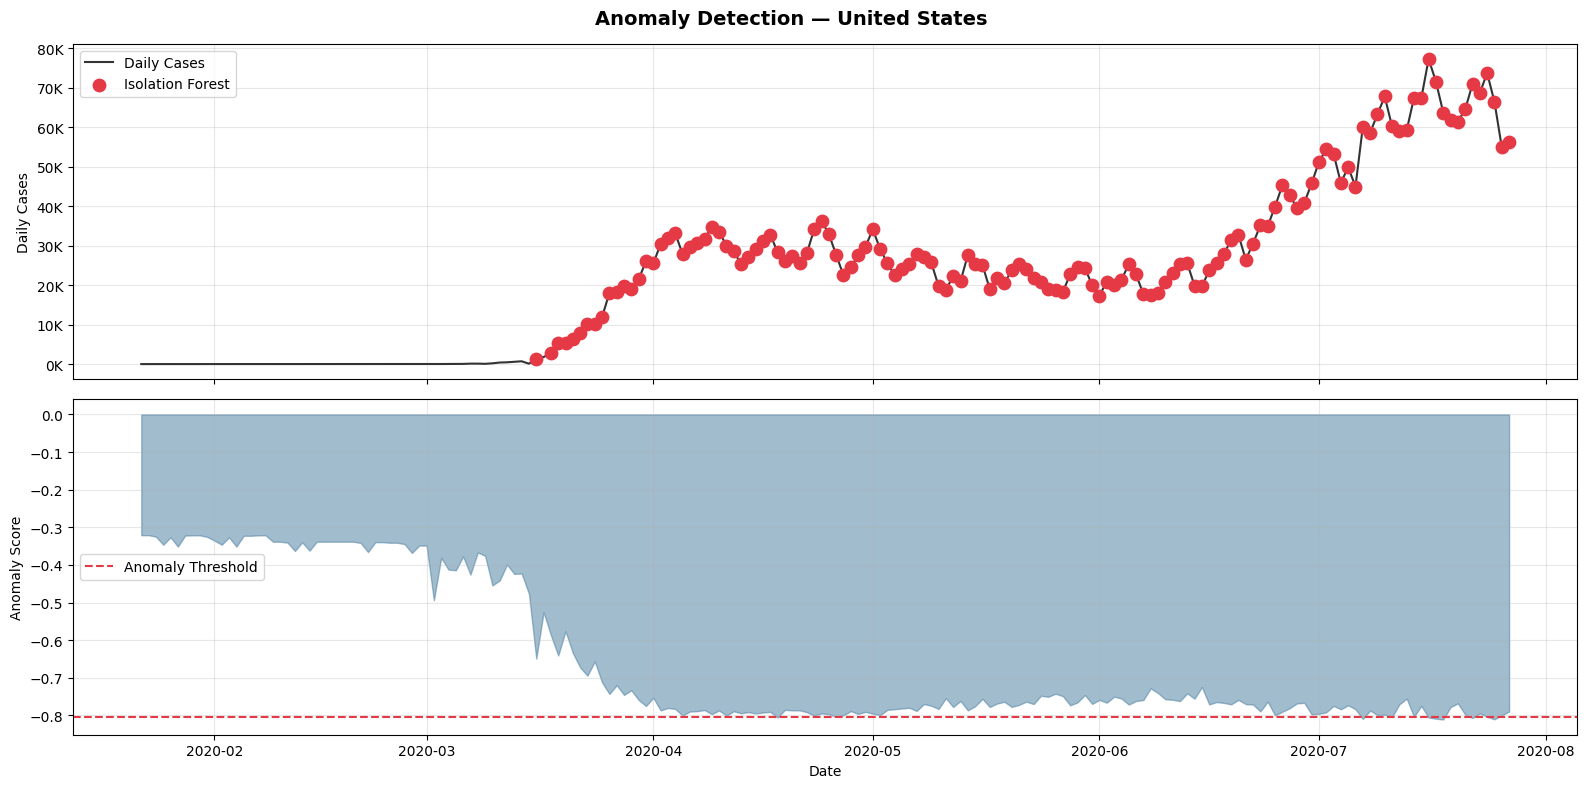

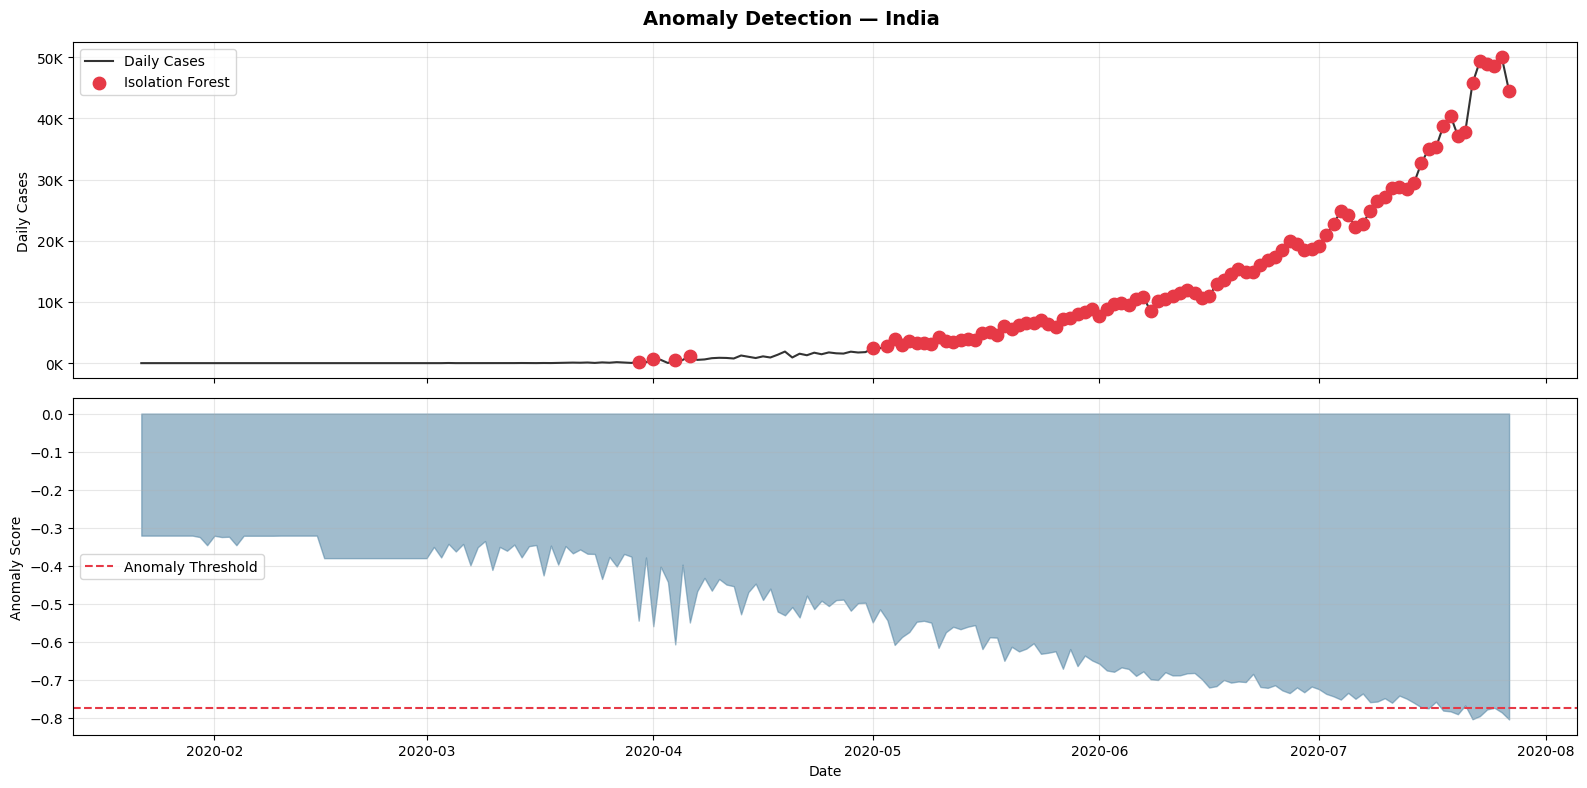

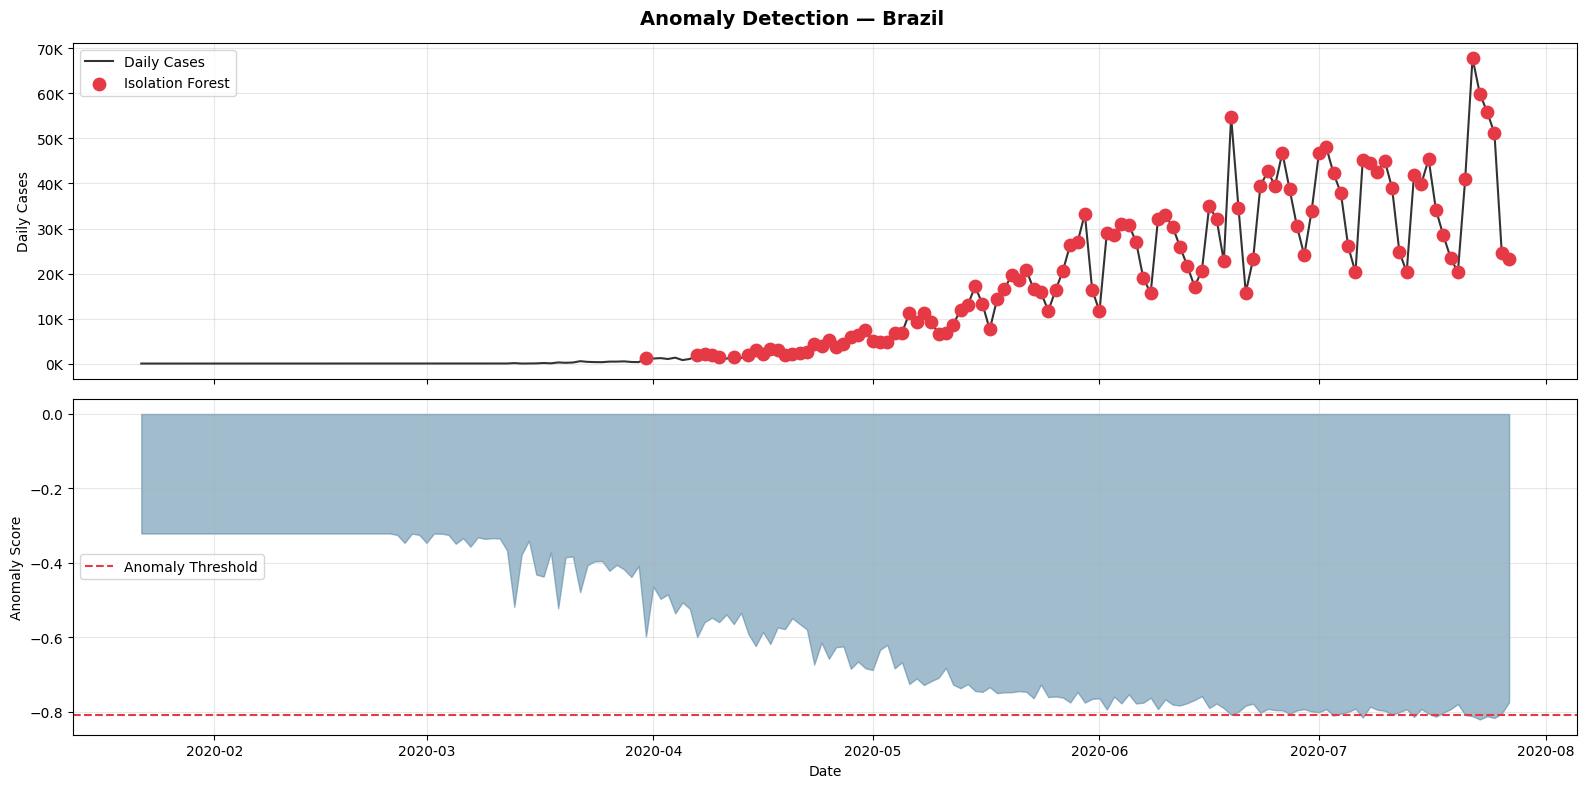


⚠️  EARLY WARNING SUMMARY:
Country
United States     133
United Kingdom    111
Brazil            111
Russia            103
France             95
Peru               93
India              91
Mexico             89
Italy              85
Iran               84
Spain              80
Chile              76
Pakistan           55
Germany            52
South Africa       49

  ✅ Saved: data/anomaly_outputs/anomaly_scores.csv

✅ STEP 5 COMPLETE — Anomaly models saved to models/


In [7]:
# ============================================================
# STEP 5: ANOMALY DETECTION
# Methods: Isolation Forest + Autoencoder
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
os.makedirs('data/anomaly_outputs', exist_ok=True)

print("=" * 60)
print("STEP 5: ANOMALY DETECTION")
print("=" * 60)

df = pd.read_csv('data/processed/features_data.csv', parse_dates=['Date'])

# ── Feature set for anomaly detection ─────────────────────
ANOMALY_FEATURES = [
    'Daily_Cases', 'Daily_Deaths', 'Growth_Rate',
    'CFR', 'Recovery_Rate', 'Case_Acceleration', 'MA_7_Cases'
]
ANOMALY_FEATURES = [f for f in ANOMALY_FEATURES if f in df.columns]

# ── Get latest per-country snapshot + time series ─────────
print(f"\nFeatures used: {ANOMALY_FEATURES}")

# ══════════════════════════════════════════════════════════
# METHOD 1: Isolation Forest
# ══════════════════════════════════════════════════════════
print("\n🌲 METHOD 1: Isolation Forest")
print("-" * 40)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Use all country-day records
adf = df[ANOMALY_FEATURES + ['Country', 'Date']].dropna()
X_all = adf[ANOMALY_FEATURES].values

scaler_anomaly = StandardScaler()
X_scaled = scaler_anomaly.fit_transform(X_all)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,    # expect ~5% anomalies
    max_features=len(ANOMALY_FEATURES),
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)
scores = iso_forest.score_samples(X_scaled)
labels = iso_forest.predict(X_scaled)   # -1 = anomaly, 1 = normal

adf = adf.copy()
adf['ISO_Score'] = scores
adf['ISO_Label'] = labels
adf['Is_Anomaly_ISO'] = labels == -1

n_anomalies = (labels == -1).sum()
print(f"  Anomalies detected: {n_anomalies} / {len(labels)} records "
      f"({n_anomalies/len(labels)*100:.1f}%)")

joblib.dump(iso_forest,    'models/isolation_forest.pkl')
joblib.dump(scaler_anomaly,'models/scaler_anomaly.pkl')
print("  ✅ Saved: models/isolation_forest.pkl")

# ══════════════════════════════════════════════════════════
# METHOD 2: LSTM Autoencoder (Advanced — Main Method)
# ══════════════════════════════════════════════════════════
print("\n🔬 METHOD 2: LSTM Autoencoder (Main)")
print("-" * 40)

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size=64, latent_size=16, seq_len=14):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len     = seq_len
        self.input_size  = input_size
        self.hidden_size = hidden_size
        
        # Encoder
        self.encoder_lstm = nn.LSTM(input_size, hidden_size,
                                     num_layers=2, batch_first=True,
                                     dropout=0.2)
        self.enc_fc = nn.Linear(hidden_size, latent_size)
        
        # Decoder
        self.dec_fc = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(hidden_size, input_size,
                                     num_layers=2, batch_first=True,
                                     dropout=0.2)
    
    def forward(self, x):
        # Encode
        enc_out, (h_n, c_n) = self.encoder_lstm(x)
        latent = self.enc_fc(enc_out[:, -1, :])
        
        # Decode
        dec_input = self.dec_fc(latent).unsqueeze(1).repeat(1, self.seq_len, 1)
        dec_out, _ = self.decoder_lstm(dec_input)
        
        return dec_out, latent

def create_ae_sequences(data, seq_len=14):
    seqs = []
    for i in range(len(data) - seq_len + 1):
        seqs.append(data[i:i+seq_len])
    return np.array(seqs)

# Train on global data (all normal-ish records)
X_normal = X_scaled[labels == 1]   # use isolation forest normals for training

SEQ_LEN = 14
X_seqs = create_ae_sequences(X_normal, SEQ_LEN)
X_tensor = torch.FloatTensor(X_seqs)

dataset = torch.utils.data.TensorDataset(X_tensor, X_tensor)
loader  = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

autoencoder = LSTMAutoencoder(
    input_size=len(ANOMALY_FEATURES),
    hidden_size=64, latent_size=16, seq_len=SEQ_LEN
)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("  Training autoencoder...")
losses = []
autoencoder.train()
for epoch in range(80):
    epoch_loss = 0
    for x_batch, _ in loader:
        optimizer.zero_grad()
        recon, _ = autoencoder(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg = epoch_loss / len(loader)
    losses.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f"    Epoch {epoch+1:3d}/80 | Recon Loss: {avg:.6f}")

# Compute reconstruction error on all data
X_all_seqs = create_ae_sequences(X_scaled, SEQ_LEN)
if len(X_all_seqs) > 0:
    X_all_tensor = torch.FloatTensor(X_all_seqs)
    autoencoder.eval()
    with torch.no_grad():
        recon_all, _ = autoencoder(X_all_tensor)
    
    recon_errors = ((X_all_tensor - recon_all) ** 2).mean(dim=(1, 2)).numpy()
    
    # Threshold: mean + 2*std
    threshold = recon_errors.mean() + 2 * recon_errors.std()
    ae_anomalies = recon_errors > threshold
    
    print(f"\n  Reconstruction error threshold: {threshold:.4f}")
    print(f"  Autoencoder anomalies: {ae_anomalies.sum()} "
          f"({ae_anomalies.mean()*100:.1f}%)")
    
    # Align indices (seq creation offsets by SEQ_LEN-1)
    adf_ae = adf.iloc[SEQ_LEN-1:SEQ_LEN-1+len(recon_errors)].copy()
    adf_ae['AE_Recon_Error'] = recon_errors
    adf_ae['Is_Anomaly_AE']  = ae_anomalies

torch.save(autoencoder.state_dict(), 'models/lstm_autoencoder.pth')
print("  ✅ Saved: models/lstm_autoencoder.pth")

# ── Visualize anomalies for a sample country ──────────────
print("\n📊 Visualizing anomalies...")

def plot_country_anomalies(country, adf_sub, title_suffix=""):
    cdf = adf_sub[adf_sub['Country'] == country].sort_values('Date')
    if len(cdf) == 0:
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'Anomaly Detection — {country} {title_suffix}',
                 fontsize=14, fontweight='bold')
    
    # Panel 1: Daily Cases with anomaly markers
    axes[0].plot(cdf['Date'], cdf['Daily_Cases'],
                 color='#333', linewidth=1.5, label='Daily Cases')
    
    if 'Is_Anomaly_ISO' in cdf.columns:
        anomalies_iso = cdf[cdf['Is_Anomaly_ISO'] == True]
        axes[0].scatter(anomalies_iso['Date'], anomalies_iso['Daily_Cases'],
                       color='#e63946', s=80, zorder=5, label='Isolation Forest')
    
    axes[0].set_ylabel('Daily Cases')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    
    # Panel 2: Anomaly score
    if 'ISO_Score' in cdf.columns:
        axes[1].fill_between(cdf['Date'], cdf['ISO_Score'],
                              alpha=0.5, color='#457b9d')
        axes[1].axhline(y=cdf['ISO_Score'].quantile(0.05),
                        color='#e63946', linestyle='--', label='Anomaly Threshold')
        axes[1].set_ylabel('Anomaly Score')
        axes[1].set_xlabel('Date')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    fname = f'data/anomaly_outputs/anomaly_{country.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

for country in ['United States', 'India', 'Brazil']:
    plot_country_anomalies(country, adf)

# ── Early Warning Summary ─────────────────────────────────
print("\n⚠️  EARLY WARNING SUMMARY:")
top_anomaly = (adf[adf['Is_Anomaly_ISO'] == True]
               .groupby('Country')['Is_Anomaly_ISO']
               .sum()
               .sort_values(ascending=False)
               .head(15))
print(top_anomaly.to_string())

# Save anomaly data
adf.to_csv('data/anomaly_outputs/anomaly_scores.csv', index=False)
print("\n  ✅ Saved: data/anomaly_outputs/anomaly_scores.csv")

print("\n" + "=" * 60)
print("✅ STEP 5 COMPLETE — Anomaly models saved to models/")
print("=" * 60)

STEP 6: RISK SCORING SYSTEM

🏷️  Building risk labels...
  Risk distribution:
Risk_Category
Low       67
Medium    64
High      56

⚙️  Preparing XGBoost features...
  Features: 21
  Samples: 187

🌳 Training XGBoost Risk Classifier...

🔁 Running Cross Validation (Manual)...
  Fold 1: Accuracy = 0.974
  Fold 2: Accuracy = 0.921
  Fold 3: Accuracy = 0.919
  Fold 4: Accuracy = 0.919
  Fold 5: Accuracy = 1.000

  ✅ CV Accuracy: 0.947 ± 0.034

🚀 Training Final Model on Full Data...

  Training Accuracy: 1.000

  Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        67
      Medium       1.00      1.00      1.00        64
        High       1.00      1.00      1.00        56

    accuracy                           1.00       187
   macro avg       1.00      1.00      1.00       187
weighted avg       1.00      1.00      1.00       187

  ROC-AUC (macro): 1.000

🔍 Feature Importance (SHAP / Fallback)...


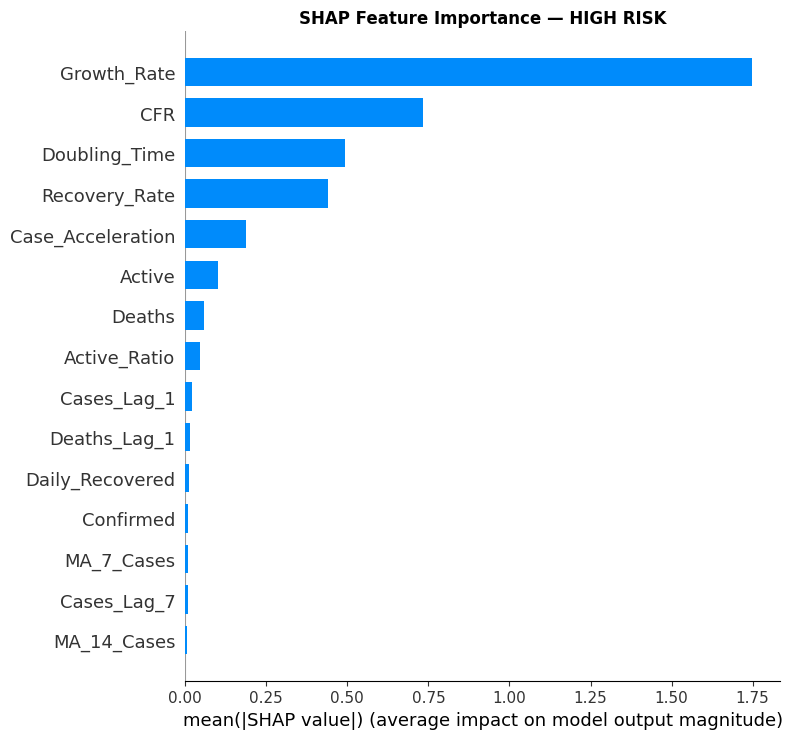

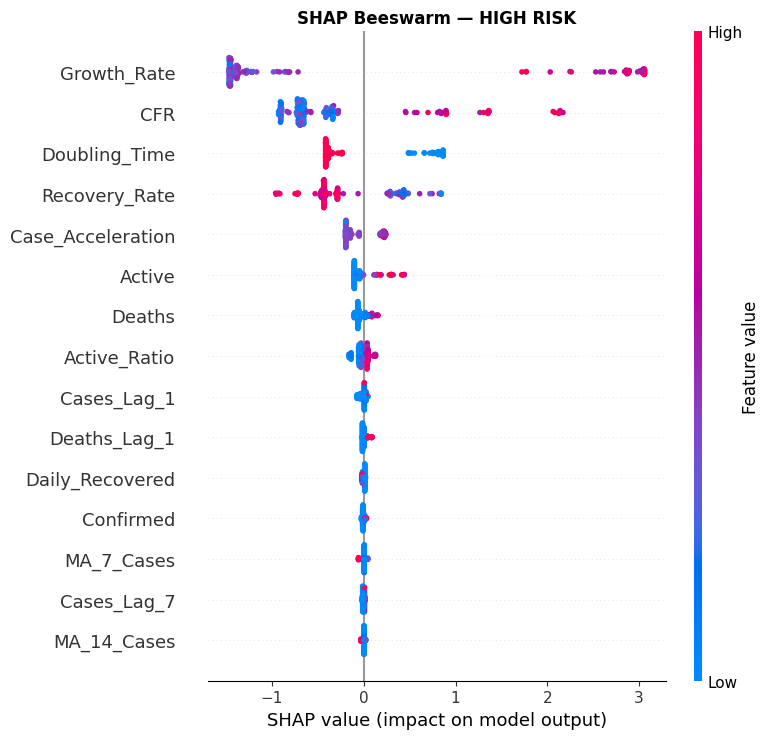

  ✅ SHAP working perfectly (fixed)


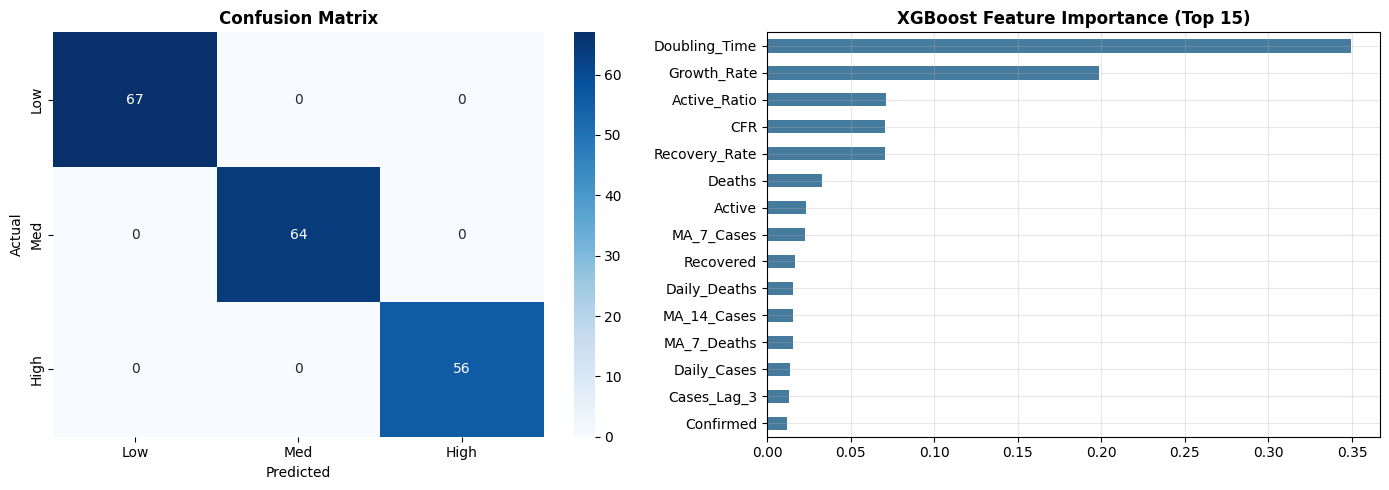


🗺️  Generating global risk map...


  ✅ Global risk map saved
  ✅ Models saved: models/xgboost_risk.pkl
  ✅ Risk scores: data/risk_outputs/country_risk_scores.csv

🔴 TOP HIGH RISK COUNTRIES:
    Country  Risk_Score       CFR  Growth_Rate  Max_Risk_Prob
    Belgium         100 14.785934    34.448161       0.997601
     Canada         100  7.680022   113.793103       0.997477
Netherlands         100 11.532773   500.000000       0.997326
     Guyana          92  5.141388    90.000000       0.994564
      Yemen          92 28.562980    42.857143       0.997155
     Greece          85  4.778803    25.925926       0.993733
    Bolivia          85  3.718689    52.613240       0.995009
     Angola          85  4.315789    12.500000       0.993420
      Libya          85  2.263884    29.508197       0.993635
    Nigeria          85  2.088392    16.756757       0.994722

✅ STEP 6 COMPLETE — Risk system ready


In [11]:
# ============================================================
# STEP 6: RISK SCORING MODEL (XGBoost + SHAP)
# Outputs: Low / Medium / High risk per country
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
os.makedirs('data/risk_outputs', exist_ok=True)

print("=" * 60)
print("STEP 6: RISK SCORING SYSTEM")
print("=" * 60)

df = pd.read_csv('data/processed/features_data.csv', parse_dates=['Date'])
wm = pd.read_csv('data/processed/worldometer_clean.csv')

# ── Build risk label using quantile-based approach ────────
print("\n🏷️  Building risk labels...")

latest = df.groupby('Country').last().reset_index()

# Risk score formula (composite)
def compute_risk_score(row):
    score = 0
    
    # CFR component (0-30 pts)
    if   row.get('CFR', 0) > 5:   score += 30
    elif row.get('CFR', 0) > 2:   score += 15
    else:                          score += 5
    
    # Growth rate component (0-30 pts)
    gr = row.get('Growth_Rate', 0)
    if   gr > 10:  score += 30
    elif gr > 5:   score += 20
    elif gr > 1:   score += 10
    else:          score += 2
    
    # Active ratio component (0-20 pts)
    ar = row.get('Active_Ratio', 0)
    if   ar > 50:  score += 20
    elif ar > 20:  score += 12
    else:          score += 4
    
    # Doubling time (0-20 pts) — shorter = riskier
    dt = row.get('Doubling_Time', 999)
    if   dt < 7:   score += 20
    elif dt < 14:  score += 12
    elif dt < 30:  score += 5
    else:          score += 0
    
    return score

latest['Risk_Score'] = latest.apply(compute_risk_score, axis=1)

# Create labels: Low / Medium / High
q33 = latest['Risk_Score'].quantile(0.33)
q66 = latest['Risk_Score'].quantile(0.66)

latest['Risk_Label'] = pd.cut(
    latest['Risk_Score'],
    bins=[-0.1, q33, q66, 100],
    labels=[0, 1, 2]        # 0=Low, 1=Medium, 2=High
).astype(int)

label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
latest['Risk_Category'] = latest['Risk_Label'].map(label_map)

print(f"  Risk distribution:")
print(latest['Risk_Category'].value_counts().to_string())

# ── Feature selection for XGBoost ────────────────────────
print("\n⚙️  Preparing XGBoost features...")

RISK_FEATURES = [
    'Confirmed', 'Deaths', 'Recovered', 'Active',
    'Daily_Cases', 'Daily_Deaths', 'Daily_Recovered',
    'Growth_Rate', 'CFR', 'Recovery_Rate', 'Active_Ratio',
    'Doubling_Time', 'Case_Acceleration',
    'MA_7_Cases', 'MA_14_Cases', 'MA_7_Deaths',
    'Cases_Lag_1', 'Cases_Lag_3', 'Cases_Lag_7',
    'Deaths_Lag_1', 'Deaths_Lag_7'
]
RISK_FEATURES = [f for f in RISK_FEATURES if f in latest.columns]

X = latest[RISK_FEATURES].fillna(0)
y = latest['Risk_Label']

print(f"  Features: {len(RISK_FEATURES)}")
print(f"  Samples: {len(X)}")

# ── Train XGBoost ─────────────────────────────────────────
print("\n🌳 Training XGBoost Risk Classifier...")

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score)
from sklearn.preprocessing import label_binarize

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ✅ Updated params (sklearn-compatible)
xgb_params = {
    'n_estimators': 300,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'objective': 'multi:softprob',   # 🔥 required for multi-class
    'num_class': 3,                  # 🔥 required
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'            # 🔥 faster & stable
}

print("\n🔁 Running Cross Validation (Manual)...")

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(**xgb_params)

    model.fit(X_train, y_train, verbose=False)

    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)

    cv_scores.append(acc)

    print(f"  Fold {fold+1}: Accuracy = {acc:.3f}")

cv_scores = np.array(cv_scores)

print(f"\n  ✅ CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Final Training (FIXED) ───────────────────────────────
print("\n🚀 Training Final Model on Full Data...")

# ✅ IMPORTANT FIX: define model again
xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(
    X, y,
    eval_set=[(X, y)],
    verbose=False
)

y_pred = xgb_model.predict(X)
y_prob = xgb_model.predict_proba(X)

print(f"\n  Training Accuracy: {accuracy_score(y, y_pred):.3f}")
print(f"\n  Classification Report:")
print(classification_report(y, y_pred, target_names=['Low', 'Medium', 'High']))

# ROC-AUC (multi-class)
y_bin = label_binarize(y, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
print(f"  ROC-AUC (macro): {roc_auc:.3f}")

# ── Add predictions to latest ─────────────────────────────
latest['XGB_Risk_Label'] = y_pred
latest['XGB_Risk_Category'] = latest['XGB_Risk_Label'].map(label_map)
latest['Risk_Prob_Low']    = y_prob[:, 0]
latest['Risk_Prob_Medium'] = y_prob[:, 1]
latest['Risk_Prob_High']   = y_prob[:, 2]
latest['Max_Risk_Prob']    = y_prob.max(axis=1)

# ── Explainability (SHAP + Fallback FIXED) ────────────────
print("\n🔍 Feature Importance (SHAP / Fallback)...")

try:
    import shap

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X)

    # 🔥 HANDLE ALL SHAP FORMATS (VERY IMPORTANT)
    if isinstance(shap_values, list):
        # Old format → list per class
        shap_high = shap_values[2]

    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # New format → (samples, features, classes)
        shap_high = shap_values[:, :, 2]

    else:
        raise ValueError("Unexpected SHAP output format")

    # ── Bar Plot ─────────────────────────────────────────
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_high,
        X,
        feature_names=RISK_FEATURES,
        plot_type='bar',
        max_display=15,
        show=False
    )
    plt.title('SHAP Feature Importance — HIGH RISK', fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/risk_outputs/shap_importance.png', dpi=150)
    plt.show()

    # ── Beeswarm Plot ────────────────────────────────────
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_high,
        X,
        feature_names=RISK_FEATURES,
        max_display=15,
        show=False
    )
    plt.title('SHAP Beeswarm — HIGH RISK', fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/risk_outputs/shap_beeswarm.png', dpi=150)
    plt.show()

    print("  ✅ SHAP working perfectly (fixed)")

    # Save values
    shap_df = pd.DataFrame(shap_high, columns=RISK_FEATURES)
    shap_df['Country'] = latest['Country'].values
    shap_df.to_csv('data/risk_outputs/shap_values.csv', index=False)

except Exception as e:
    print(f"  ⚠️ SHAP failed ({e}) → using fallback")

    from sklearn.inspection import permutation_importance

    result = permutation_importance(
        xgb_model, X, y,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importances = pd.Series(result.importances_mean, index=RISK_FEATURES)
    importances = importances.sort_values()

    plt.figure(figsize=(10, 6))
    importances.tail(15).plot(kind='barh')
    plt.title('Feature Importance (Permutation Importance)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data/risk_outputs/fallback_importance.png', dpi=150)
    plt.show()

    print("  ✅ Fallback importance used (stable)")
    
   
# ── Confusion Matrix ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, y_pred)
sns_import = False
try:
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Med', 'High'],
                yticklabels=['Low', 'Med', 'High'],
                ax=axes[0])
    sns_import = True
except:
    axes[0].imshow(cm, cmap='Blues')

axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (XGBoost built-in)
fi = pd.Series(xgb_model.feature_importances_, index=RISK_FEATURES).sort_values()
fi.tail(15).plot(kind='barh', ax=axes[1], color='#457b9d')
axes[1].set_title('XGBoost Feature Importance (Top 15)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/risk_outputs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Risk Map ──────────────────────────────────────────────
print("\n🗺️  Generating global risk map...")

try:
    import plotly.express as px
    
    risk_color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    
    fig = px.choropleth(
        latest,
        locations='Country',
        locationmode='country names',
        color='XGB_Risk_Category',
        color_discrete_map=risk_color_map,
        hover_name='Country',
        hover_data={
            'XGB_Risk_Category': True,
            'Risk_Score': True,
            'CFR': ':.2f',
            'Growth_Rate': ':.2f',
            'Max_Risk_Prob': ':.2%'
        },
        title='Global COVID-19 Risk Level by Country (XGBoost Model)',
        template='plotly_white'
    )
    fig.update_layout(height=550)
    fig.write_html('data/risk_outputs/global_risk_map.html')
    fig.show()
    print("  ✅ Global risk map saved")
except Exception as e:
    print(f"  ⚠️  Map error: {e}")

# ── Save models & data ────────────────────────────────────
joblib.dump(xgb_model,    'models/xgboost_risk.pkl')
joblib.dump(RISK_FEATURES,'models/risk_features.pkl')

latest.to_csv('data/risk_outputs/country_risk_scores.csv', index=False)
print("  ✅ Models saved: models/xgboost_risk.pkl")
print("  ✅ Risk scores: data/risk_outputs/country_risk_scores.csv")

# ── Print top risky countries ─────────────────────────────
print("\n🔴 TOP HIGH RISK COUNTRIES:")
high_risk = (latest[latest['XGB_Risk_Category'] == 'High']
             [['Country', 'Risk_Score', 'CFR', 'Growth_Rate', 'Max_Risk_Prob']]
             .sort_values('Risk_Score', ascending=False)
             .head(10))
print(high_risk.to_string(index=False))

print("\n" + "=" * 60)
print("✅ STEP 6 COMPLETE — Risk system ready")
print("=" * 60)